## MiniMonuNet : Indian Monument Classifier

This project builds a CNN-based image classifier that can identify 24 Indian landmarks from low-quality or blurry images using transfer learning and Grad-CAM for explainability.


### 1. Loading and Preparing Dataset


In [ ]:
# Importing necessary libraries
import zipfile
import os

# Path to zip file
zip_path = "/content/dataset.zip"

# Extracting zipfile
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

# Confirming file structure
for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    break

/content/dataset


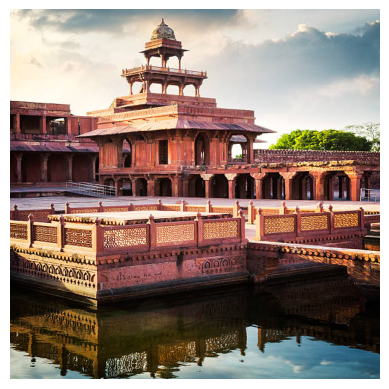

In [ ]:
# Displaying image from dataset
from PIL import Image
import matplotlib.pyplot as plt

img_path = "/content/dataset/dataset/images/train/fatehpur_sikri/1.jpg"
img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
plt.show()

### 2. Defining Transforms and DataLoaders


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transforms
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomApply([
        transforms.GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 2.0)),
        transforms.ColorJitter(brightness=0.5, contrast=0.5),
    ], p=0.7),
    transforms.RandomRotation(degrees=10),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])


In [ ]:
# Changing .jfif to .jpg
test_root = "/content/dataset/dataset/images/test"

for root, dirs, files in os.walk(test_root):
    for fname in files:
        if fname.lower().endswith(".jfif"):
            old_path = os.path.join(root, fname)
            new_fname = fname.rsplit(".", 1)[0] + ".jpg"
            new_path = os.path.join(root, new_fname)
            os.rename(old_path, new_path)
            print(f"Renamed: {old_path} → {new_path}")


Renamed: /content/dataset/dataset/images/test/charminar/39.jfif → /content/dataset/dataset/images/test/charminar/39.jpg
Renamed: /content/dataset/dataset/images/test/charminar/16.jfif → /content/dataset/dataset/images/test/charminar/16.jpg
Renamed: /content/dataset/dataset/images/test/charminar/9.jfif → /content/dataset/dataset/images/test/charminar/9.jpg
Renamed: /content/dataset/dataset/images/test/charminar/23.jfif → /content/dataset/dataset/images/test/charminar/23.jpg
Renamed: /content/dataset/dataset/images/test/charminar/13.jfif → /content/dataset/dataset/images/test/charminar/13.jpg
Renamed: /content/dataset/dataset/images/test/charminar/5.jfif → /content/dataset/dataset/images/test/charminar/5.jpg
Renamed: /content/dataset/dataset/images/test/charminar/7.jfif → /content/dataset/dataset/images/test/charminar/7.jpg
Renamed: /content/dataset/dataset/images/test/charminar/38.jfif → /content/dataset/dataset/images/test/charminar/38.jpg
Renamed: /content/dataset/dataset/images/test/

In [ ]:
from torchvision.datasets import ImageFolder

# Defining paths
train_dir = "/content/dataset/dataset/images/train"
test_dir = "/content/dataset/dataset/images/test"

# Loading datasets using ImageFolder
train_dataset = ImageFolder(train_dir, transform=train_transforms)
test_dataset = ImageFolder(test_dir, transform=test_transforms)


# Creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

# Printing class-to-index mapping and sample sizes
print("Class to index mapping:", train_dataset.class_to_idx)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


Class to index mapping: {'ajanta_caves': 0, 'alai_darwaza': 1, 'alai_minar': 2, 'basilica_of_bom_jesus': 3, 'charar_e_sharif': 4, 'charminar': 5, 'chhota_imambara': 6, 'ellora_caves': 7, 'fatehpur_sikri': 8, 'gateway_of_india': 9, 'golden_temple': 10, 'hawa_mahal': 11, 'humayuns_tomb': 12, 'india_gate': 13, 'iron_pillar': 14, 'jamali_kamali_tomb': 15, 'khajuraho': 16, 'lotus_temple': 17, 'mysore_palace': 18, 'qutub_minar': 19, 'sun_temple_konark': 20, 'tajmahal': 21, 'tanjavur_temple': 22, 'victoria_memorial': 23}
Train samples: 3669
Test samples: 1059


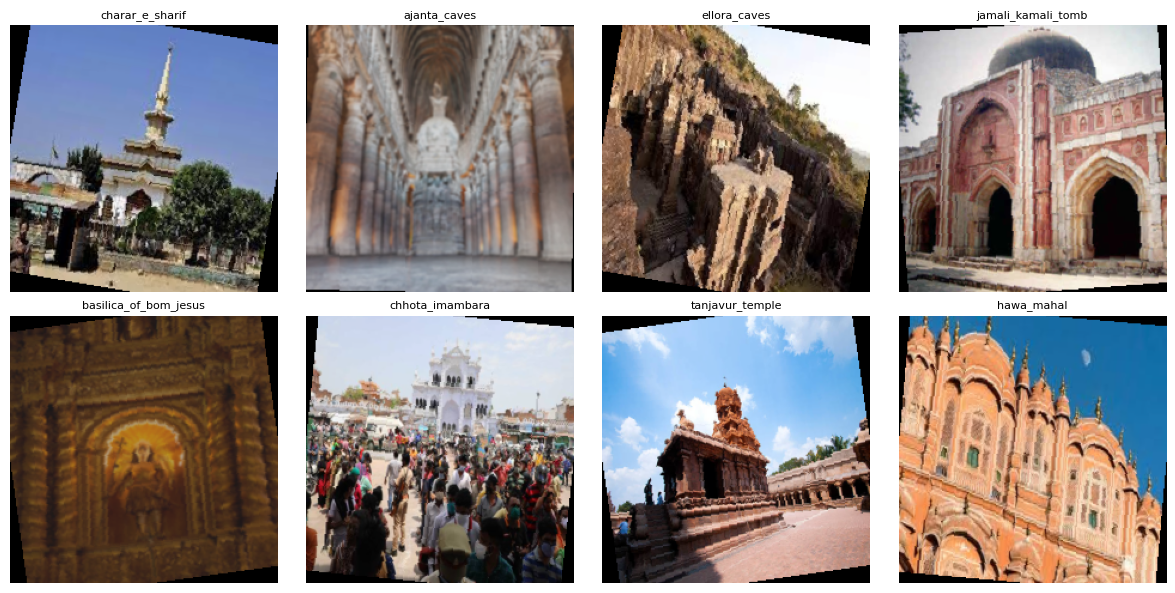

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Helper function to unnormalize and convert tensor to image
def imshow(img_tensor):
    img_tensor = img_tensor.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = std * img_tensor + mean
    img = np.clip(img, 0, 1)
    plt.imshow(img)

# Get one batch of training data
dataiter = iter(train_loader)
images, labels = next(dataiter)

# Plotting first 8 images
plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    class_name = train_dataset.classes[labels[i]]
    plt.title(class_name, fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


### 3. Loading and Training the Model

In [ ]:
import torch.nn as nn
import torchvision.models as models

# Checking for GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Loading pretrained ResNet18
model = models.resnet18(pretrained=True)

# Freezing earlier layers
for param in model.parameters():
    param.requires_grad = False

# Replacing the final layer for 24-class classification
num_classes = len(train_dataset.classes)

model.fc = nn.Linear(model.fc.in_features, num_classes)

# Move model to GPU/CPU
model = model.to(device)


Using device: cpu


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 113MB/s]


In [ ]:
# Training function
def train_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=10):
    model.to(device)

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            # Backward + optimize
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Stats
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

        train_acc = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs} - Loss: {running_loss:.4f}, Accuracy: {train_acc:.2f}%")

    print("Training complete.")


In [ ]:
import torch.optim as optim

# Loss function: CrossEntropyLoss for multi-class classification
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [ ]:
train_model(model, train_loader, test_loader, criterion, optimizer, device, num_epochs=5)

Epoch 1/5 - Loss: 247.3524, Accuracy: 45.54%
Epoch 2/5 - Loss: 134.0096, Accuracy: 75.17%
Epoch 3/5 - Loss: 100.7105, Accuracy: 79.53%
Epoch 4/5 - Loss: 82.9748, Accuracy: 83.24%
Epoch 5/5 - Loss: 74.6269, Accuracy: 84.30%
Training complete.


### 4. Evaluating Model on Test Set



In [ ]:
def evaluate_model(model, test_loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")


In [ ]:
evaluate_model(model, test_loader, device)


Test Accuracy: 85.08%


### 5. Random Predictions from Test Set

In [ ]:
# displaying images with results
import random

def show_random_test_images(model, dataset, device, num_images=8):
    model.eval()
    indices = list(range(len(dataset)))
    random.shuffle(indices)

    plt.figure(figsize=(15, 6))
    shown = 0

    with torch.no_grad():
        for idx in indices:
            img, label = dataset[idx]
            input_tensor = img.unsqueeze(0).to(device)
            output = model(input_tensor)
            _, pred = torch.max(output, 1)

            img_np = img.permute(1, 2, 0).numpy()
            img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
            img_np = np.clip(img_np, 0, 1)

            plt.subplot(2, 4, shown + 1)
            plt.imshow(img_np)
            pred_class = dataset.classes[pred.item()]
            true_class = dataset.classes[label]
            color = "green" if pred_class == true_class else "red"
            plt.title(f"Pred: {pred_class}\nTrue: {true_class}", color=color, fontsize=9)
            plt.axis("off")
            shown += 1
            if shown >= num_images:
                break

    plt.tight_layout()
    plt.show()


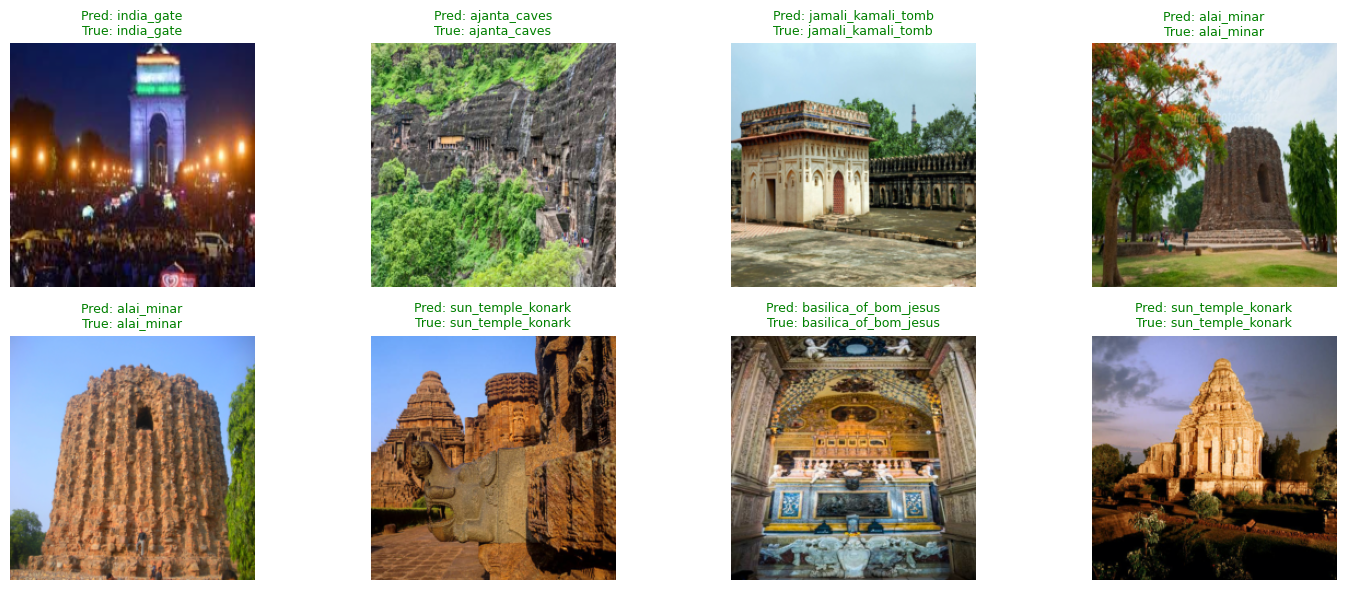

In [ ]:
show_random_test_images(model, test_dataset, device)


In [ ]:
import torchvision.transforms.functional as TF
import torchvision.transforms as T

def test_robustness_on_image(model, dataset, device, mode='blur'):
    model.eval()
    idx = random.randint(0, len(dataset)-1)
    image, label = dataset[idx]

    # Applying selected degradation
    if mode == 'blur':
        degraded = TF.gaussian_blur(image, kernel_size=9)  # heavier blur
    elif mode == 'dark':
        degraded = TF.adjust_brightness(image, 0.2)
    elif mode == 'noise':
        noise = torch.randn_like(image) * 0.2
        degraded = torch.clamp(image + noise, 0, 1)
    elif mode == 'crop':
        degraded = TF.center_crop(image, [120, 120])
        degraded = TF.resize(degraded, [224, 224])
    elif mode == 'rotate':
        angle = random.choice([30, 45, 60, 90])
        degraded = TF.rotate(image, angle)
    elif mode == 'perspective':
        degraded = T.RandomPerspective(distortion_scale=0.5, p=1.0)(image)
    elif mode == 'occlusion':
        degraded = image.clone()
        c, h, w = degraded.shape
        occl_x = random.randint(0, w - 60)
        occl_y = random.randint(0, h - 60)
        degraded[:, occl_y:occl_y+60, occl_x:occl_x+60] = 0  # black square
    else:
        degraded = image

    # Prediction
    input_tensor = degraded.unsqueeze(0).to(device)
    with torch.no_grad():
        output = model(input_tensor)
        _, pred = torch.max(output, 1)

    # Visualize
    img_np = degraded.permute(1, 2, 0).numpy()
    img_np = img_np * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_np = np.clip(img_np, 0, 1)

    plt.imshow(img_np)
    plt.axis("off")
    true_class = dataset.classes[label]
    pred_class = dataset.classes[pred.item()]
    title_color = "green" if pred_class == true_class else "red"
    plt.title(f"Pred: {pred_class}\nTrue: {true_class}", color=title_color, fontsize=10)
    plt.show()


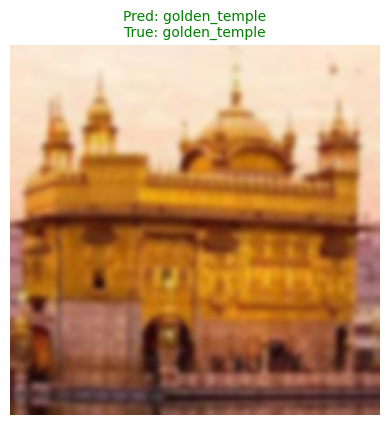

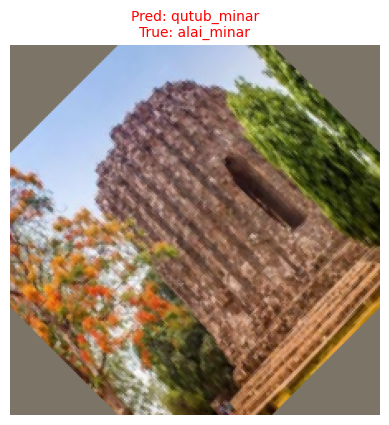

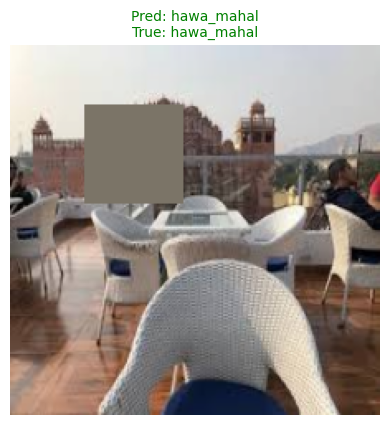

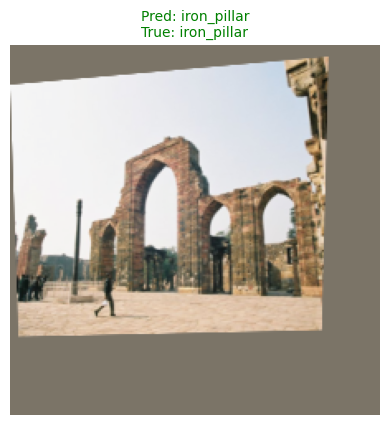

In [ ]:
test_robustness_on_image(model, test_dataset, device, mode='blur')
test_robustness_on_image(model, test_dataset, device, mode='rotate')
test_robustness_on_image(model, test_dataset, device, mode='occlusion')
test_robustness_on_image(model, test_dataset, device, mode='perspective')


### 6. Saving the model

Display a few randomly chosen test images along with the model's predicted and true labels.


In [ ]:
# Saving model weights
model_save_path = "/content/lazy_landmark_model.pth"
torch.save(model.state_dict(), model_save_path)

print(f"Model saved to: {model_save_path}")


Model saved to: /content/lazy_landmark_model.pth


In [ ]:
import json

# Save class-to-index mapping
with open("/content/class_to_idx.json", "w") as f:
    json.dump(train_dataset.class_to_idx, f)


### 7. Grad-CAM Setup and Visualization

In [ ]:
!pip install grad-cam --quiet


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 25.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 98.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.3 MB/s e

In [ ]:
#importing necessary libraries

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import preprocess_image

import cv2

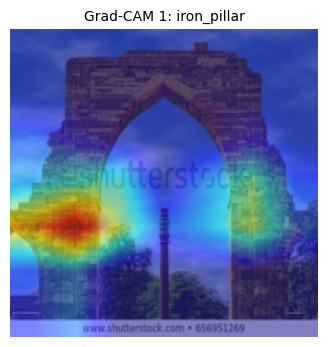

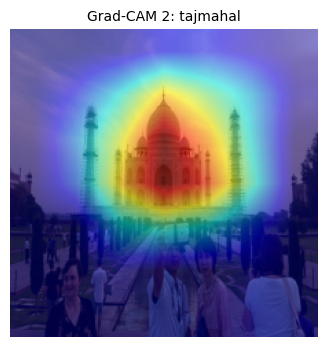

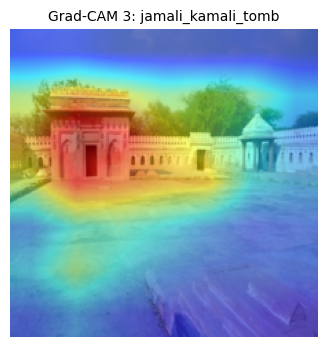

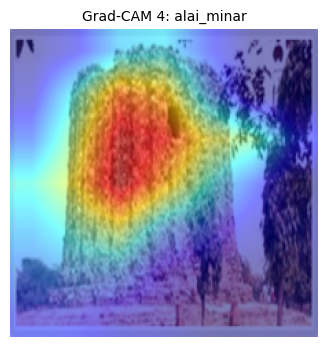

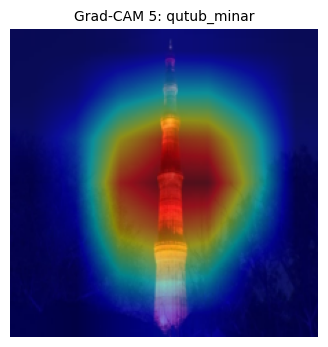

In [ ]:
# Grad-CAM setup
target_layers = [model.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

# Running Grad-CAM on 5 random test images
num_samples = 5

for i in range(num_samples):
    img_tensor, label = test_dataset[random.randint(0, len(test_dataset)-1)]
    input_tensor = img_tensor.unsqueeze(0).to(device)

    rgb_img = img_tensor.permute(1, 2, 0).cpu().numpy()
    rgb_img = rgb_img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    rgb_img = np.clip(rgb_img, 0, 1)

    input_tensor.requires_grad = True
    targets = [ClassifierOutputTarget(label)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(4, 4))
    plt.imshow(visualization)
    plt.axis('off')
    plt.title(f"Grad-CAM {i+1}: {test_dataset.classes[label]}", fontsize=10)
    plt.savefig(f"/content/gradcam_{i+1}.png", bbox_inches='tight')
    plt.show()
